# 01: Open Bandit EDA

This notebook starts  **Off-Policy Evaluation of Recommendation Systems**.

## What Is The Off-Policy Evaluation Problem?

Recommendation systems are usually changed through policies. A policy is a rule that maps a user context to a probability distribution over possible actions. In this project, the action is the item shown to the user, the context is the information available before the recommendation, and the reward is whether the user clicked.

The central product question asks **how a new recommendation policy would perform if deployed.** In an online experiment, we could answer this by randomly assigning users to the new policy and directly observing clicks. But online experiments can be expensive, slow, risky, or unavailable during early research. Off-policy evaluation, usually shortened to OPE, tries to estimate the value of a new policy using historical logs collected by a different policy.

The historical policy is called the **behavior policy** or **logging policy**. It is the policy that actually chose the items in the data. The new policy we want to evaluate is called the **evaluation policy**. The difficulty is that each logged row only shows one action and one reward: the item that was actually recommended and whether it was clicked. We do not observe what the same user would have done if a different item had been shown. That missing counterfactual is the causal inference problem.

Open Bandit is useful because it logs the behavior-policy probability for the selected action. This probability is called the **propensity score**. If the behavior policy gave an action probability `p`, then rows with small `p` represent actions that were unlikely under the logger. Importance-based OPE estimators use these propensities to reweight logged outcomes so the historical data can mimic the action distribution of a different evaluation policy.

The simplest idea is inverse propensity scoring. If the evaluation policy would choose the logged action with probability `pi_e` and the behavior policy chose it with probability `pi_b`, then the row receives weight `pi_e / pi_b`. Rows that the evaluation policy likes more than the behavior policy get upweighted. Rows that the evaluation policy would rarely choose get downweighted. Averaging these weighted rewards estimates the value of the evaluation policy.

This only works under important assumptions. First, the logged propensities must be correct. Second, the behavior policy must have positive probability for actions the evaluation policy might choose; this is called support or positivity. Third, the logged context must be rich enough that comparing policy choices is meaningful. Even when these assumptions hold, IPS can have high variance when propensities are small, so later notebooks will compare IPS with self-normalized IPS and doubly robust estimators.

The goal of this first notebook is not to estimate a new policy yet. The goal is to verify that the Open Bandit logs contain the ingredients required for OPE:

- a logged action, `item_id`
- an observed reward, `click`
- a logging-policy probability, `propensity_score`
- context features available before the recommendation was made
- enough action support so a future evaluation policy can be compared against the behavior policy

We will use the `random/men` campaign first because the random behavior policy is easier to reason about than an adaptive bandit policy. This gives us a clean foundation before moving to IPS, SNIPS, and doubly robust policy value estimation.


## Project Framing

### What You Will Build

This project builds an off-policy evaluation workflow for recommendation policies using Open Bandit Dataset logs. You will audit the logged behavior policy, estimate alternative policy values with IPS, SNIPS, direct method, and doubly robust estimators, then study clipping, sensitivity, reward-model diagnostics, and contextual policy learning.

### How To Use This Project

Work through the notebooks in order. This first notebook explains the data and the OPE design problem. The middle notebooks build the estimators and diagnostics. The final public notebook learns and compares contextual policy candidates. The report notebook is mainly an artifact builder for figures, tables, and summary files.

### Data Source And Scope

The analysis uses Open Bandit Dataset logs from a fashion e-commerce recommendation setting. The data include context features, actions, click rewards, and known behavior-policy propensities. This makes the project suitable for studying how offline policy evaluation depends on support, propensity quality, and estimator stability.

<!-- dataset-experiment-context -->
## Dataset and Experiment Context

This project uses the Open Bandit Dataset from a fashion e-commerce recommendation setting. Each row is a logged recommendation event with context features, the item action chosen by the behavior policy, a binary click reward, and the behavior-policy propensity for the chosen action.

The main analysis uses the `random/men` campaign because randomized logging gives broad action support and known propensities. Open Bandit also contains adaptive Bernoulli Thompson Sampling logs, but random logging is the cleanest starting point for off-policy evaluation.

The offline experiment asks which candidate recommendation policy deserves online validation. IPS, SNIPS, direct method, doubly robust estimates, effective sample size, clipping sensitivity, and reward-model diagnostics are treated as launch-readiness evidence for later online testing.

**Role of this notebook.** This notebook verifies that Open Bandit has the OPE ingredients needed for later work: logged actions, rewards, contexts, and positive behavior-policy propensities.

<!-- mathematical-setup -->

## Mathematical Setup

Open Bandit data records contexts, actions, rewards, and the behavior policy that generated the logged action. For row \(i\), the logged observation is

$$
O_i=(X_i,A_i,R_i,b(A_i\mid X_i)),
$$

where \(X_i\) is context, \(A_i\) is the logged action, \(R_i\) is the reward, and \(b(a\mid X_i)\) is the logging probability. The value of a target policy \(\pi\) is

$$
V(\pi)=\mathbb{E}\left[\sum_a \pi(a\mid X_i)r(a,X_i)\right].
$$

Exploratory analysis checks whether the logged data can support that value estimate. If a target policy chooses actions that the behavior policy rarely chose, then \(b(A_i\mid X_i)\) is small and off-policy estimates become unstable.


#### Setup

This cell imports the libraries used throughout the notebook. `pandas` handles the tabular logs, `numpy` supports numerical summaries, `matplotlib` and `seaborn` create plots, and `zipfile` lets us read the Open Bandit data directly from the downloaded zip without manually extracting the full archive.

The display settings make wide Open Bandit tables easier to inspect because the dataset contains many user-item affinity columns.


In [1]:
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:.6f}".format)

sns.set_theme(style="whitegrid", context="notebook")


This cell prepares the notebook environment for Open Bandit data understanding and OPE readiness. There is no estimator output yet; the main value is that the imports, display settings, and plotting defaults are ready for the OPE diagnostics that follow.


#### Locate The Dataset

This cell finds the repository root by walking upward from the current working directory until it sees the downloaded Open Bandit zip. This makes the notebook work whether it is launched from the repository root, from `notebooks/`, or from `notebooks/projects/project_2_off_policy_evaluation/`.

We keep the zip file as the source of truth. The Open Bandit files are large, so reading only the campaign we need is cleaner than extracting everything.


In [2]:
OPEN_BANDIT_ZIP_RELATIVE_PATH = Path("data/open_bandit/open_bandit_dataset.zip")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / OPEN_BANDIT_ZIP_RELATIVE_PATH).exists()
)

OPEN_BANDIT_ZIP = PROJECT_ROOT / OPEN_BANDIT_ZIP_RELATIVE_PATH
PROCESSED_DIR = PROJECT_ROOT / "data/processed"

OPEN_BANDIT_ZIP


PosixPath('/home/apex/Documents/portfolio/data/open_bandit/open_bandit_dataset.zip')

The printed paths are a reproducibility checkpoint. Once the notebook can find the cached data and writeup folders, the rest of the analysis can run without manual path edits.


#### Inspect The Zip Contents

Before loading data, we inspect the archive inventory. This confirms which behavior policies and campaigns are available.

Open Bandit includes two behavior policies:

- `random`: a randomized logging policy, useful as the cleanest starting point for OPE
- `bts`: a Bernoulli Thompson Sampling policy, useful later for comparing adaptive logging behavior

It also includes three campaigns: `all`, `men`, and `women`. We begin with `random/men` because it is smaller and has a simple action space.


In [3]:
with ZipFile(OPEN_BANDIT_ZIP) as zf:
    zip_inventory = pd.DataFrame(
        [
            {
                "path": info.filename,
                "size_mb": info.file_size / 1_000_000,
                "is_dir": info.is_dir(),
            }
            for info in zf.infolist()
        ]
    )

zip_inventory.query("not is_dir").sort_values("path")


,path,size_mb,is_dir
0,open_bandit_dataset/README,0.002659,False
11,open_bandit_dataset/VERSION,0.000034,False
2,open_bandit_dataset/bts/all/all.csv,6321.017454,False
1,open_bandit_dataset/bts/all/item_context.csv,0.010041,False
4,open_bandit_dataset/bts/men/item_context.csv,0.004287,False
5,open_bandit_dataset/bts/men/men.csv,1332.891122,False
7,open_bandit_dataset/bts/women/item_context.csv,0.005792,False
8,open_bandit_dataset/bts/women/women.csv,2913.666740,False
13,open_bandit_dataset/random/all/all.csv,695.501426,False
12,open_bandit_dataset/random/all/item_context.csv,0.010041,False


The archive inventory confirms which Open Bandit files are available and where they live inside the zip. This prevents accidental use of the wrong campaign, behavior policy, or file split before OPE begins.


#### Choose The First Analysis Slice

This cell defines the campaign files for Notebook 1. We use:

- behavior policy: `random`
- campaign: `men`
- logged data file: `open_bandit_dataset/random/men/men.csv`
- item context file: `open_bandit_dataset/random/men/item_context.csv`

The full `random/men` file is already large, so the first notebook reads a sample of rows. This is enough for EDA and support checks, while keeping iteration fast. Later notebooks can increase `SAMPLE_ROWS` or read the full file if needed.


In [4]:
BEHAVIOR_POLICY = "random"
CAMPAIGN = "men"
SAMPLE_ROWS = 200_000

LOG_MEMBER = f"open_bandit_dataset/{BEHAVIOR_POLICY}/{CAMPAIGN}/{CAMPAIGN}.csv"
ITEM_CONTEXT_MEMBER = f"open_bandit_dataset/{BEHAVIOR_POLICY}/{CAMPAIGN}/item_context.csv"

pd.DataFrame(
    {
        "setting": ["behavior_policy", "campaign", "sample_rows", "log_member", "item_context_member"],
        "value": [BEHAVIOR_POLICY, CAMPAIGN, SAMPLE_ROWS, LOG_MEMBER, ITEM_CONTEXT_MEMBER],
    }
)


,setting,value
0,behavior_policy,random
1,campaign,men
2,sample_rows,200000
3,log_member,open_bandit_dataset/random/men/men.csv
4,item_context_member,open_bandit_dataset/random/men/item_context.csv


This selection fixes the first behavior-policy and campaign slice for inspection. OPE depends heavily on the logging policy, so choosing the slice explicitly keeps later propensity and support checks easy to interpret.


#### Read The Dataset Documentation

The zip includes a short README describing the dataset. We print the relevant excerpt so the notebook itself records why this dataset is appropriate for off-policy evaluation.

The key phrase for this project is that each logged row contains a selected action, a reward, and the true propensity score from the behavior policy. Those are exactly the three quantities required for basic OPE estimators.


In [5]:
with ZipFile(OPEN_BANDIT_ZIP) as zf:
    readme_text = zf.read("open_bandit_dataset/README").decode("utf-8")

print(readme_text[:1800])


# Open Bandit Dataset

This is the full size version of *Open Bandit Dataset* that can be used for research on bandit algorithms and off-policy evaluation.
The small size example version of our data is available at https://github.com/st-tech/zr-obp/tree/master/obd

This dataset is released along with the paper:

Yuta Saito, Shunsuke Aihara, Megumi Matsutani, Yusuke Narita.
A Large-scale Open Dataset for Bandit Algorithms. https://arxiv.org/abs/2008.07146

When using this dataset, please cite the paper with following bibtex:

@article{saito2020large,
  title={A Large-scale Open Dataset for Bandit Algorithms},
  author={Saito, Yuta, Shunsuke Aihara, Megumi Matsutani, Yusuke Narita},
  journal={arXiv preprint arXiv:2008.07146},
  year={2020}
}


## Data description
Open Bandit Dataset is constructed in an A/B test of two multi-armed bandit policies in a large-scale fashion e-commerce platform, ZOZOTOWN (https://zozo.jp/).
It currently consists of a total of 26M rows, each one representing

Reading the documentation anchors the column meanings before modeling. For OPE, this is especially important because reward, action, position, and propensity fields each have a specific estimator role.


#### Load Logged Impressions

This cell loads the first `SAMPLE_ROWS` from the selected Open Bandit campaign. The first column in the CSV is an unnamed index created when the dataset was exported, so we load it with `index_col=0`.

Each row is a logged recommendation event at a specific position. The important causal fields are:

- `item_id`: the action chosen by the behavior policy
- `click`: the observed reward
- `propensity_score`: the probability that the behavior policy assigned to the logged action
- user and affinity features: context available for modeling rewards or evaluation policies


In [6]:
with ZipFile(OPEN_BANDIT_ZIP) as zf:
    with zf.open(LOG_MEMBER) as f:
        df = pd.read_csv(f, nrows=SAMPLE_ROWS, index_col=0)

df.head()


,timestamp,item_id,position,click,propensity_score,user_feature_0,user_feature_1,user_feature_2,user_feature_3,user-item_affinity_0,user-item_affinity_1,user-item_affinity_2,user-item_affinity_3,user-item_affinity_4,user-item_affinity_5,user-item_affinity_6,user-item_affinity_7,user-item_affinity_8,user-item_affinity_9,user-item_affinity_10,user-item_affinity_11,user-item_affinity_12,user-item_affinity_13,user-item_affinity_14,user-item_affinity_15,user-item_affinity_16,user-item_affinity_17,user-item_affinity_18,user-item_affinity_19,user-item_affinity_20,user-item_affinity_21,user-item_affinity_22,user-item_affinity_23,user-item_affinity_24,user-item_affinity_25,user-item_affinity_26,user-item_affinity_27,user-item_affinity_28,user-item_affinity_29,user-item_affinity_30,user-item_affinity_31,user-item_affinity_32,user-item_affinity_33
0,2019-11-24 00:00:03.800821+00:00,0,1,0,0.029412,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2019-11-24 00:00:03.801019+00:00,25,3,0,0.029412,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2019-11-24 00:00:03.801099+00:00,23,2,0,0.029412,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2019-11-24 00:00:17.634355+00:00,25,1,0,0.029412,1a2b2ad3a7f218a0d709dd9c656fda27,e3528f5280f04c0031d337da1def86ea,398773dacf8501ee8f76e3706ccafbba,47e7dd7d9ccbe31d57ce716dba831d44,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2019-11-24 00:00:17.634998+00:00,30,2,0,0.029412,1a2b2ad3a7f218a0d709dd9c656fda27,e3528f5280f04c0031d337da1def86ea,398773dacf8501ee8f76e3706ccafbba,47e7dd7d9ccbe31d57ce716dba831d44,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


The loaded table shape and preview confirm that the expected cached data is available. This check matters because all later OPE estimates depend on using the correct logged actions, rewards, contexts, and behavior propensities.


#### Load Item Context

The log contains user-side context and action identifiers. The item context table gives item-level features for the available actions in this campaign.

We load this separately because later notebooks can use item features when learning reward models for doubly robust OPE. In this notebook, the item context mostly helps us understand the action space and confirm that each `item_id` has metadata.


In [7]:
with ZipFile(OPEN_BANDIT_ZIP) as zf:
    with zf.open(ITEM_CONTEXT_MEMBER) as f:
        item_context = pd.read_csv(f, index_col=0)

item_context.head()


,item_id,item_feature_0,item_feature_1,item_feature_2,item_feature_3
0,0,-0.677183,ce58bf66d7e62186e6ce01bafeea9d39,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c
1,1,-0.720300,3c2985d744e0d57c261abd7e541e4263,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c
2,2,0.745662,3c2985d744e0d57c261abd7e541e4263,2b851c0a9c4a961da8760d5dc747c5a3,b61cfaadd526b816e3aeb9b7be4b4759
3,3,-0.698741,9874ffb54e9b0a269e29bbb2f5328735,ce1abd8b5d914ba8fe719b453bc5ba3b,5bc9c86cd1f08a9991670ea97b34f86d
4,4,1.651109,01fe2f187e459e6ada960671d2942dfe,b4b5879029fb5f64eeec63cf4f73ef0e,b61cfaadd526b816e3aeb9b7be4b4759


The loaded table shape and preview confirm that the expected cached data is available. This check matters because all later OPE estimates depend on using the correct logged actions, rewards, contexts, and behavior propensities.


#### Basic Shape

This cell summarizes the size of the sample and the item context table. For OPE, the number of rows matters because importance weighting can have high variance. The number of actions matters because a larger action space usually makes overlap harder.

In the `men` campaign, the action space is much smaller than the `all` campaign, which makes it a good first notebook for clean reasoning.


In [8]:
basic_shape = pd.DataFrame(
    {
        "object": ["logged_sample", "item_context"],
        "rows": [len(df), len(item_context)],
        "columns": [df.shape[1], item_context.shape[1]],
    }
)

basic_shape


,object,rows,columns
0,logged_sample,200000,43
1,item_context,34,5


The shape summary gives the scale of the logged recommendation data. OPE estimators can be noisy, so knowing the number of impressions, actions, and rewards gives context for every later uncertainty and support diagnostic.


#### Column Groups

Open Bandit has a compact schema, but the many affinity columns can make the table look intimidating. This cell groups the columns into interpretable families.

The affinity columns are especially important for later modeling. They are precomputed user-item affinity scores, meaning they can help predict clicks without using post-treatment information.


In [9]:
user_feature_cols = [col for col in df.columns if col.startswith("user_feature_")]
affinity_cols = [col for col in df.columns if col.startswith("user-item_affinity_")]
core_cols = ["timestamp", "item_id", "position", "click", "propensity_score"]
item_feature_cols = [col for col in item_context.columns if col.startswith("item_feature_")]

column_groups = pd.DataFrame(
    {
        "group": ["core logged fields", "user features", "user-item affinity features", "item features"],
        "n_columns": [len(core_cols), len(user_feature_cols), len(affinity_cols), len(item_feature_cols)],
        "columns": [core_cols, user_feature_cols, affinity_cols[:5] + ["..."], item_feature_cols],
    }
)

column_groups


,group,n_columns,columns
0,core logged fields,5,"[timestamp, item_id, position, click, propensi..."
1,user features,4,"[user_feature_0, user_feature_1, user_feature_..."
2,user-item affinity features,34,"[user-item_affinity_0, user-item_affinity_1, u..."
3,item features,4,"[item_feature_0, item_feature_1, item_feature_..."


This output clarifies which columns describe users, items, actions, rewards, and propensities. That separation keeps the OPE setup clean: actions and rewards are targets of evaluation, while context fields support modeling and diagnostics.


### Column Dictionary

This cell creates a lightweight dictionary for the main columns in the logged data. The point is to make the causal roles explicit:

- `item_id` is the action
- `click` is the reward
- `propensity_score` is the behavior-policy probability
- the remaining features are context

That mapping will carry through the rest of the off-policy evaluation notebooks.


In [10]:
column_dictionary = pd.DataFrame(
    [
        ("timestamp", "time", "When the recommendation impression happened."),
        ("item_id", "action", "The item selected by the behavior policy."),
        ("position", "slot/context", "The UI position where the item was shown: 1, 2, or 3."),
        ("click", "reward", "Binary outcome: 1 if the user clicked, 0 otherwise."),
        ("propensity_score", "logging probability", "Probability that the behavior policy selected the logged action."),
        ("user_feature_*", "context", "Categorical user-side features available before recommendation."),
        ("user-item_affinity_*", "context", "Precomputed affinity scores between user context and candidate items."),
        ("item_feature_*", "action context", "Item metadata that can be joined by item_id."),
    ],
    columns=["field", "causal_role", "description"],
)

column_dictionary


,field,causal_role,description
0,timestamp,time,When the recommendation impression happened.
1,item_id,action,The item selected by the behavior policy.
2,position,slot/context,"The UI position where the item was shown: 1, 2..."
3,click,reward,"Binary outcome: 1 if the user clicked, 0 other..."
4,propensity_score,logging probability,Probability that the behavior policy selected ...
5,user_feature_*,context,Categorical user-side features available befor...
6,user-item_affinity_*,context,Precomputed affinity scores between user conte...
7,item_feature_*,action context,Item metadata that can be joined by item_id.


This output clarifies which columns describe users, items, actions, rewards, and propensities. That separation keeps the OPE setup clean: actions and rewards are targets of evaluation, while context fields support modeling and diagnostics.


#### Data Types

This cell checks the raw data types. The user feature columns are hashed categorical values, the affinity columns are numeric, and the reward and propensity fields are numeric.

This matters because later reward models will need preprocessing: categorical columns should be encoded, while numeric affinity features can be passed directly into many models.


In [11]:
dtype_summary = (
    df.dtypes.astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)

dtype_summary


,column,dtype
0,timestamp,str
1,item_id,int64
2,position,int64
3,click,int64
4,propensity_score,float64
5,user_feature_0,str
6,user_feature_1,str
7,user_feature_2,str
8,user_feature_3,str
9,user-item_affinity_0,float64


This output clarifies which columns describe users, items, actions, rewards, and propensities. That separation keeps the OPE setup clean: actions and rewards are targets of evaluation, while context fields support modeling and diagnostics.


#### Missing Values

This cell computes the missing-value rate for every column and keeps only columns with nonzero missingness.

For OPE, missingness is part of the causal diagnostics. If important context fields are missing systematically, a learned evaluation policy or reward model may be biased toward the rows where those features are present.


In [12]:
missing = df.isna().mean().sort_values(ascending=False).rename("missing_rate")
missing[missing > 0]


Series([], Name: missing_rate, dtype: float64)

The missingness check shows whether key OPE fields are complete. Missing rewards, actions, or propensity scores would be a serious blocker because IPS, SNIPS, and DR all depend on those logged quantities.


#### Parse Time Features

The raw timestamp is useful, but Open Bandit stores some timestamps with fractional seconds and some without them. For EDA, we parse these mixed timestamp strings and create simple calendar features such as date and hour. These are context features because they are known at recommendation time.

Time features can matter in recommendation systems because user intent and traffic patterns change over a day. Later, if an evaluation policy performs well only during certain hours, that would be a product-relevant heterogeneity finding.


In [13]:
df = df.assign(
    timestamp=pd.to_datetime(df["timestamp"], utc=True, format="mixed"),
)
df = df.assign(
    date=df["timestamp"].dt.date,
    hour=df["timestamp"].dt.hour,
)

df[["timestamp", "date", "hour"]].head()


,timestamp,date,hour
0,2019-11-24 00:00:03.800821+00:00,2019-11-24,0
1,2019-11-24 00:00:03.801019+00:00,2019-11-24,0
2,2019-11-24 00:00:03.801099+00:00,2019-11-24,0
3,2019-11-24 00:00:17.634355+00:00,2019-11-24,0
4,2019-11-24 00:00:17.634998+00:00,2019-11-24,0


The parsed time features and coverage summary show when the logging data was collected. Time matters because policy behavior, item popularity, and reward rates can drift across the log window.


### Reward and Action Summary

This cell summarizes the core bandit quantities:

- sample size
- click rate
- number of distinct actions
- number of positions
- propensity range

A good first OPE dataset should have observed rewards, positive propensities, and enough action variation. The click rate also tells us how sparse the reward signal is.


In [14]:
summary = pd.Series(
    {
        "rows": len(df),
        "click_rate": df["click"].mean(),
        "clicked_rows": int(df["click"].sum()),
        "unique_items": df["item_id"].nunique(),
        "unique_positions": df["position"].nunique(),
        "min_propensity": df["propensity_score"].min(),
        "max_propensity": df["propensity_score"].max(),
        "mean_propensity": df["propensity_score"].mean(),
    }
).to_frame("value")

summary


,value
rows,200000.000000
click_rate,0.005190
clicked_rows,1038.000000
unique_items,34.000000
unique_positions,3.000000
min_propensity,0.029412
max_propensity,0.029412
mean_propensity,0.029412


The reward and action summaries establish the base click rate and action space. Since clicks are sparse, later OPE estimates need careful variance and effective-sample-size diagnostics.


#### Click Distribution

Clicks are usually rare in recommendation logs. This cell counts clicked and non-clicked rows so the class imbalance is visible.

This matters for the next notebooks because rare rewards make policy value estimates noisy. Even with known propensities, a policy that places high weight on a small number of clicked events can have unstable IPS estimates.


In [15]:
click_counts = (
    df["click"]
    .value_counts()
    .rename_axis("click")
    .reset_index(name="rows")
    .assign(rate=lambda x: x["rows"] / x["rows"].sum())
)

click_counts


,click,rows,rate
0,0,198962,0.994810
1,1,1038,0.005190


The reward and action summaries establish the base click rate and action space. Since clicks are sparse, later OPE estimates need careful variance and effective-sample-size diagnostics.


#### Plot Click Distribution

This plot visualizes the reward imbalance from the previous table. The bar for `click = 0` will be much larger than the bar for `click = 1`, which is expected for click logs.

The purpose is not to make a causal claim yet. It simply tells us that future policy-value estimators will be estimating a small expected reward.


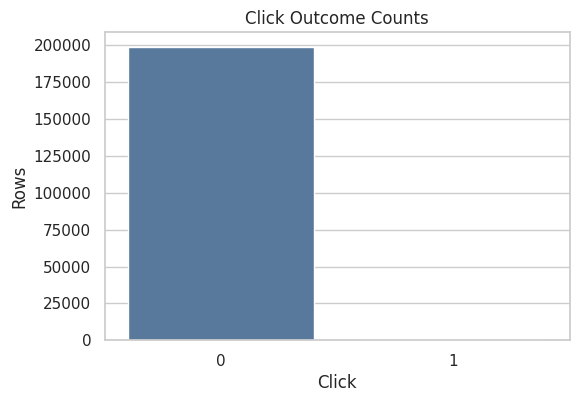

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=click_counts, x="click", y="rows", ax=ax, color="#4C78A8")
ax.set_title("Click Outcome Counts")
ax.set_xlabel("Click")
ax.set_ylabel("Rows")
plt.show()


The reward and action summaries establish the base click rate and action space. Since clicks are sparse, later OPE estimates need careful variance and effective-sample-size diagnostics.


#### Position Distribution

The `position` column describes where the selected item was displayed. In this interface, positions 1, 2, and 3 correspond to the available recommendation slots.

For off-policy evaluation, position is best treated as context. The action is the recommended item, while position can affect click probability and should be considered in reward modeling.


In [17]:
position_summary = (
    df.groupby("position")
    .agg(rows=("click", "size"), click_rate=("click", "mean"), avg_propensity=("propensity_score", "mean"))
    .reset_index()
    .assign(row_share=lambda x: x["rows"] / x["rows"].sum())
)

position_summary


,position,rows,click_rate,avg_propensity,row_share
0,1,66653,0.005746,0.029412,0.333265
1,2,66679,0.005114,0.029412,0.333395
2,3,66668,0.004710,0.029412,0.333340


The position summary checks where logged recommendations appeared in the slate. Position can affect reward, so understanding its distribution helps interpret later policy-value comparisons. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Plot Position-Level CTR

This plot compares click rates across recommendation positions. A position effect is common in recommender systems because users see and react to slots differently.

This is useful context for later OPE. If an evaluation policy changes which items appear in which positions, the reward model should account for position because impressions are not fully exchangeable.


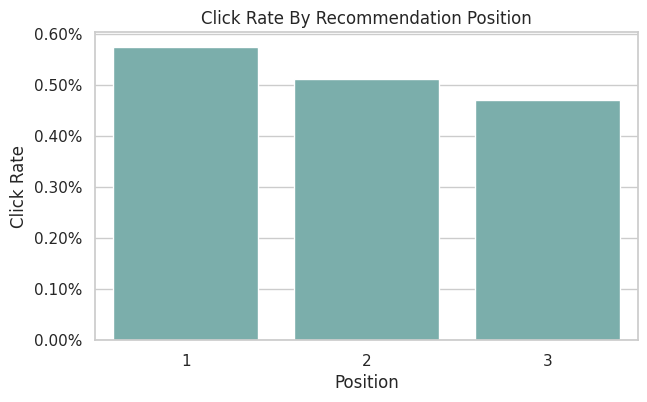

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=position_summary, x="position", y="click_rate", ax=ax, color="#72B7B2")
ax.set_title("Click Rate By Recommendation Position")
ax.set_xlabel("Position")
ax.set_ylabel("Click Rate")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
plt.show()


The position CTR plot shows whether click rates vary by slate position. Logged reward is shaped by both presentation context and item identity.


#### Action Distribution

This cell counts how often each item was recommended in the sample. Under a random logging policy, we expect the item distribution to be relatively even, though small sample variation is normal.

Action support is central to OPE. If an evaluation policy chooses items that the behavior policy almost never selected, importance weights become large and estimates become unreliable.


In [19]:
action_summary = (
    df.groupby("item_id")
    .agg(rows=("click", "size"), click_rate=("click", "mean"), avg_propensity=("propensity_score", "mean"))
    .reset_index()
    .assign(row_share=lambda x: x["rows"] / x["rows"].sum())
    .sort_values("rows", ascending=False)
)

action_summary.head(15)


,item_id,rows,click_rate,avg_propensity,row_share
7,7,6473,0.005562,0.029412,0.032365
22,22,6316,0.006175,0.029412,0.031580
11,11,6234,0.004491,0.029412,0.031170
17,17,6171,0.006482,0.029412,0.030855
25,25,6150,0.004065,0.029412,0.030750
19,19,6091,0.005254,0.029412,0.030455
6,6,6082,0.006084,0.029412,0.030410
2,2,6064,0.005607,0.029412,0.030320
32,32,6048,0.003638,0.029412,0.030240
0,0,6024,0.005644,0.029412,0.030120


The action distribution shows how often each item was logged. OPE relies on support: evaluation policies are only credible where the behavior policy logged enough comparable actions. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Plot Action Exposure Shares

This plot shows how much exposure each item receives in the random-policy sample. A nearly flat profile supports the idea that the behavior policy is exploring the action space broadly.

This is one reason Open Bandit is excellent for  the random policy creates a strong baseline for learning and evaluating alternative recommendation policies.


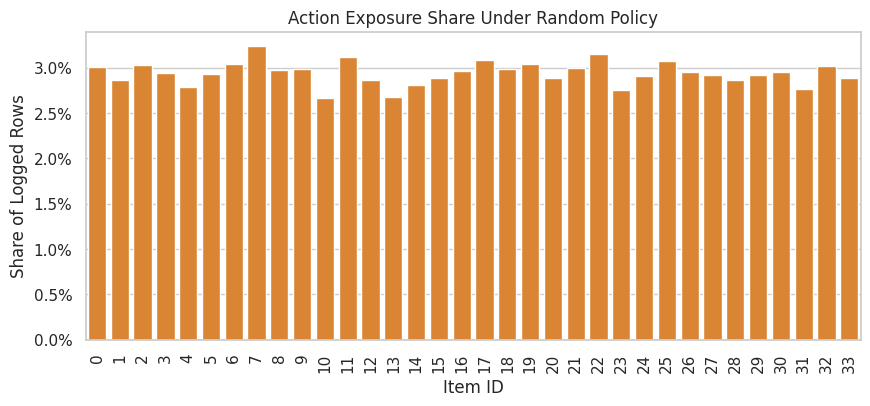

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=action_summary.sort_values("item_id"), x="item_id", y="row_share", ax=ax, color="#F58518")
ax.set_title("Action Exposure Share Under Random Policy")
ax.set_xlabel("Item ID")
ax.set_ylabel("Share of Logged Rows")
ax.tick_params(axis="x", rotation=90)
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
plt.show()


The action exposure plot reveals whether the logging policy spreads probability broadly or concentrates on a few items. Concentration creates support risk for policies that choose rarely logged actions.


### Propensity Score Summary

The propensity score is the probability assigned by the behavior policy to the logged action. For basic IPS, each row receives weight `evaluation_policy_probability / behavior_policy_probability`.

This cell summarizes the logged propensities. Positive propensities are required for support. Very small propensities imply potentially large inverse-propensity weights, which can inflate estimator variance.


In [21]:
propensity_summary = df["propensity_score"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("propensity_score")
propensity_summary


,propensity_score
count,200000.000000
mean,0.029412
std,0.000000
min,0.029412
1%,0.029412
5%,0.029412
50%,0.029412
95%,0.029412
99%,0.029412
max,0.029412


The propensity diagnostics show how much probability the behavior policy assigned to logged actions. Small propensities imply large inverse-propensity weights, which can make IPS estimates unstable. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Plot Propensity Scores

This histogram shows the distribution of logged propensities. In a simple random policy over a fixed action set, this distribution should be concentrated around a constant value.

If this plot had a long left tail near zero, IPS would be risky. A stable random-policy propensity distribution is a good sign for the first OPE notebook sequence.


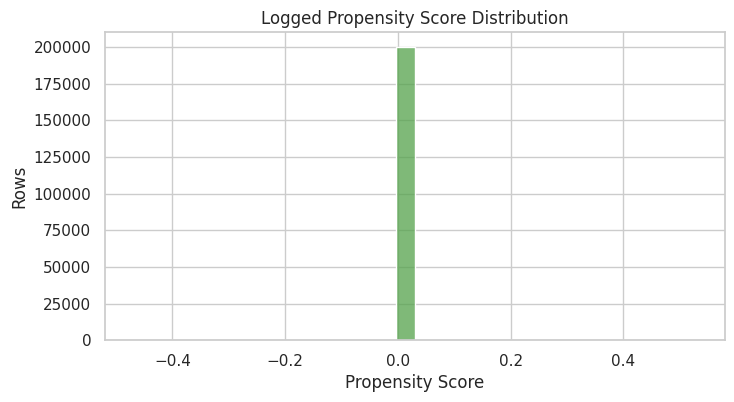

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["propensity_score"], bins=30, ax=ax, color="#54A24B")
ax.set_title("Logged Propensity Score Distribution")
ax.set_xlabel("Propensity Score")
ax.set_ylabel("Rows")
plt.show()


The propensity diagnostics show how much probability the behavior policy assigned to logged actions. Small propensities imply large inverse-propensity weights, which can make IPS estimates unstable. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Check Random-Policy Uniformity

For the `random/men` campaign, the behavior policy should assign roughly equal probability across the available actions for a given position. This cell compares the observed propensity score to `1 / number_of_actions`.

This is a sanity check. In OPE we should use the propensities provided by the logging system. This check helps build trust that the data slice behaves as expected.


In [23]:
n_actions = df["item_id"].nunique()
expected_uniform_propensity = 1 / n_actions

uniformity_check = pd.Series(
    {
        "n_actions": n_actions,
        "expected_uniform_propensity": expected_uniform_propensity,
        "observed_min_propensity": df["propensity_score"].min(),
        "observed_max_propensity": df["propensity_score"].max(),
        "max_abs_difference_from_uniform": (df["propensity_score"] - expected_uniform_propensity).abs().max(),
    }
).to_frame("value")

uniformity_check


,value
n_actions,34.000000
expected_uniform_propensity,0.029412
observed_min_propensity,0.029412
observed_max_propensity,0.029412
max_abs_difference_from_uniform,0.000000


The uniformity check tests whether the random logging policy behaves as expected. Random logs are especially valuable for OPE because they usually provide broader support than production-style adaptive policies.


### Inverse Propensity Weight Risk

Even before defining an evaluation policy, we can inspect the inverse behavior propensity `1 / propensity_score`. This is the largest multiplier that appears when an evaluation policy puts all its probability on a logged action.

For random logging over many actions, inverse propensities can still be sizable. This is why later notebooks will compare IPS with self-normalized IPS and doubly robust estimators.


In [24]:
df = df.assign(inverse_behavior_propensity=1 / df["propensity_score"])

inverse_propensity_summary = df["inverse_behavior_propensity"].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).to_frame("inverse_behavior_propensity")

inverse_propensity_summary


,inverse_behavior_propensity
count,200000.000000
mean,34.000000
std,0.000000
min,34.000000
1%,34.000000
5%,34.000000
50%,34.000000
95%,34.000000
99%,34.000000
max,34.000000


The inverse-propensity summary translates logging probabilities into variance risk. Large inverse propensities warn that a small number of rows may receive large weight in IPS-style estimators.


### Effective Sample Size Illustration

Effective sample size is a rough diagnostic for weight concentration. The formula used here is:

`ESS = (sum weights)^2 / sum(weights^2)`

For this first check, we use inverse behavior propensities only. This is not the final OPE weight because we have not defined an evaluation policy yet. It simply illustrates the kind of diagnostic we will reuse once evaluation-policy probabilities are available.


In [25]:
weights = df["inverse_behavior_propensity"].to_numpy()
effective_sample_size = weights.sum() ** 2 / np.square(weights).sum()

pd.Series(
    {
        "rows": len(df),
        "illustrative_effective_sample_size": effective_sample_size,
        "ess_share_of_rows": effective_sample_size / len(df),
    }
).to_frame("value")


,value
rows,200000.000000
illustrative_effective_sample_size,200000.000000
ess_share_of_rows,1.000000


Effective sample size turns weight concentration into an intuitive sample-size diagnostic. A low ESS means the estimator has less usable information than the raw row count suggests.


#### User Feature Cardinality

The user feature columns are hashed categorical features. This cell counts their distinct values in the sample.

High-cardinality categorical features can be useful for prediction, but they require careful encoding. For Notebook 1, we only inspect them. In later notebooks, simple baselines may use a smaller feature set before moving to richer models.


In [26]:
user_feature_cardinality = pd.DataFrame(
    {
        "column": user_feature_cols,
        "unique_values": [df[col].nunique(dropna=False) for col in user_feature_cols],
        "missing_rate": [df[col].isna().mean() for col in user_feature_cols],
    }
)

user_feature_cardinality


,column,unique_values,missing_rate
0,user_feature_0,4,0.000000
1,user_feature_1,6,0.000000
2,user_feature_2,10,0.000000
3,user_feature_3,10,0.000000


The cardinality table shows how granular the user context features are. High-cardinality context can support personalization, but it also increases the modeling burden for reward models and contextual policies.


#### Affinity Feature Summary

The user-item affinity columns are numeric scores. This cell summarizes them in a compact way by reporting average, standard deviation, and the share of zeros.

The zero share matters because many affinity features may be sparse. Sparse affinity signals are still valuable, but they influence what kind of reward model is appropriate later.


In [27]:
affinity_summary = pd.DataFrame(
    {
        "column": affinity_cols,
        "mean": [df[col].mean() for col in affinity_cols],
        "std": [df[col].std() for col in affinity_cols],
        "zero_share": [(df[col] == 0).mean() for col in affinity_cols],
    }
).sort_values("mean", ascending=False)

affinity_summary.head(15)


,column,mean,std,zero_share
14,user-item_affinity_14,0.011320,0.120756,0.989925
29,user-item_affinity_29,0.006325,0.095263,0.994605
0,user-item_affinity_0,0.005415,0.079282,0.994900
11,user-item_affinity_11,0.003345,0.059278,0.996745
3,user-item_affinity_3,0.002580,0.052472,0.997510
7,user-item_affinity_7,0.002565,0.052043,0.997510
30,user-item_affinity_30,0.002340,0.049240,0.997705
18,user-item_affinity_18,0.002130,0.048944,0.998005
2,user-item_affinity_2,0.001835,0.045185,0.998270
10,user-item_affinity_10,0.001695,0.041499,0.998320


The affinity summaries show which user preference signals vary meaningfully in the log. These features can help reward models learn context-dependent click patterns in later notebooks. The result should be read together with support diagnostics because a good reward model cannot fully rescue evaluation when the logging policy rarely explored the relevant actions.


#### Plot Top Affinity Signals

This plot shows the affinity columns with the largest average values. It helps identify which affinity dimensions carry the most signal in the sample.

This is not feature importance yet. It is only a descriptive check of the logged context features.


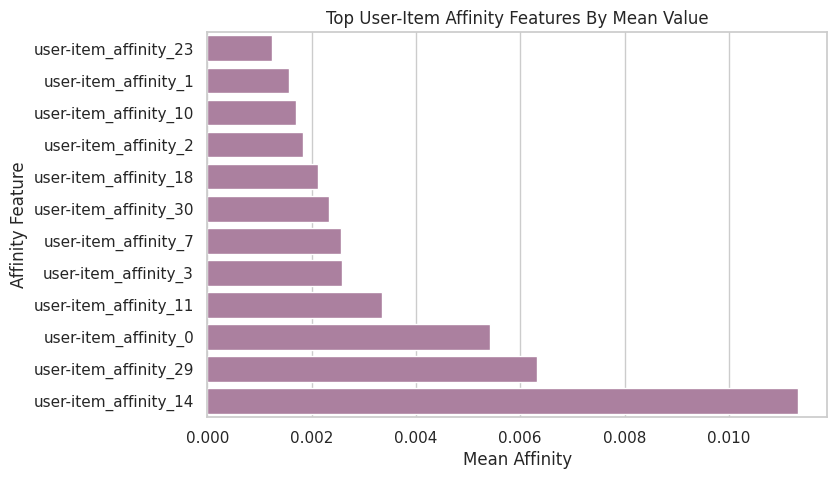

In [28]:
top_affinity = affinity_summary.head(12).sort_values("mean")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top_affinity, x="mean", y="column", ax=ax, color="#B279A2")
ax.set_title("Top User-Item Affinity Features By Mean Value")
ax.set_xlabel("Mean Affinity")
ax.set_ylabel("Affinity Feature")
plt.show()


The affinity summaries show which user preference signals vary meaningfully in the log. These features can help reward models learn context-dependent click patterns in later notebooks. The result should be read together with support diagnostics because a good reward model cannot fully rescue evaluation when the logging policy rarely explored the relevant actions.


### Join Item Context

This cell merges item metadata onto the logged rows by `item_id`. A successful merge confirms that each logged action has item-side context.

Item features are useful for later reward modeling and policy learning because they let us generalize beyond raw item IDs. For example, a policy might learn that certain item feature patterns perform better for certain user contexts.


In [29]:
df_with_items = df.merge(item_context, on="item_id", how="left", validate="many_to_one")

merge_check = pd.Series(
    {
        "rows_before_merge": len(df),
        "rows_after_merge": len(df_with_items),
        "item_feature_missing_rows": df_with_items[item_feature_cols].isna().any(axis=1).sum(),
    }
).to_frame("value")

merge_check


,value
rows_before_merge,200000
rows_after_merge,200000
item_feature_missing_rows,0


The item-context output confirms that item metadata can be attached to logged actions. This improves later reward models because OPE needs to predict rewards for all candidate actions that a policy may choose.


#### Item Feature Missingness

After the join, we check missingness in the item feature columns. Low or zero missingness means the item context table cleanly covers the actions appearing in the logged data.

This is important because doubly robust OPE depends on a reward model. Missing item features can make the reward model weaker or force extra imputation choices.


In [30]:
item_missing = (
    df_with_items[item_feature_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
)

item_missing


item_feature_0   0.000000
item_feature_1   0.000000
item_feature_2   0.000000
item_feature_3   0.000000
Name: missing_rate, dtype: float64

The missingness check shows whether key OPE fields are complete. Missing rewards, actions, or propensity scores would be a serious blocker because IPS, SNIPS, and DR all depend on those logged quantities.


#### Item Context Preview

This cell shows one row per item after joining item-level metadata to action-level click summaries. It gives a compact view of which items are common, which items have high click rates, and what metadata is attached to them.

This is useful for product storytelling: later we can explain that the evaluation policy is choosing among real items with observable item features, not abstract treatment labels.


In [31]:
item_profile = (
    action_summary.merge(item_context, on="item_id", how="left")
    .sort_values("click_rate", ascending=False)
)

item_profile.head(15)


,item_id,rows,click_rate,avg_propensity,row_share,item_feature_0,item_feature_1,item_feature_2,item_feature_3
30,31,5526,0.010496,0.029412,0.027630,-0.461600,55fe518d85813954c7d9b8a875ff2453,7c63a6aa72e655abd1787c2e64385e6f,bbf748c6c978938bc63d432efa60191c
20,27,5834,0.009085,0.029412,0.029170,-0.849649,61c5d8c2524684aa047e15e172c7e92f,5d5dd3635cb3f84d3a70f5874a132d44,5bc9c86cd1f08a9991670ea97b34f86d
31,23,5519,0.008154,0.029412,0.027595,-0.569392,55fe518d85813954c7d9b8a875ff2453,cc75031396a5aa830885915aa93f49d0,b61cfaadd526b816e3aeb9b7be4b4759
28,14,5619,0.007475,0.029412,0.028095,-1.000557,9874ffb54e9b0a269e29bbb2f5328735,3f1feafd79578bedf199c459fecc378b,bbf748c6c978938bc63d432efa60191c
32,13,5348,0.007105,0.029412,0.026740,0.616313,9874ffb54e9b0a269e29bbb2f5328735,697cbf60c7c4b8569c149721231538c3,b61cfaadd526b816e3aeb9b7be4b4759
25,12,5735,0.006800,0.029412,0.028675,1.198386,ce58bf66d7e62186e6ce01bafeea9d39,697cbf60c7c4b8569c149721231538c3,b61cfaadd526b816e3aeb9b7be4b4759
3,17,6171,0.006482,0.029412,0.030855,-0.698741,9874ffb54e9b0a269e29bbb2f5328735,5d5dd3635cb3f84d3a70f5874a132d44,5bc9c86cd1f08a9991670ea97b34f86d
1,22,6316,0.006175,0.029412,0.031580,-0.698741,61c5d8c2524684aa047e15e172c7e92f,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c
6,6,6082,0.006084,0.029412,0.030410,1.651109,ce58bf66d7e62186e6ce01bafeea9d39,7082af732502f0981a9fe77d7ba1ae8a,b61cfaadd526b816e3aeb9b7be4b4759
10,21,5997,0.005836,0.029412,0.029985,-0.698741,9874ffb54e9b0a269e29bbb2f5328735,ce1abd8b5d914ba8fe719b453bc5ba3b,5bc9c86cd1f08a9991670ea97b34f86d


The item-context output confirms that item metadata can be attached to logged actions. This improves later reward models because OPE needs to predict rewards for all candidate actions that a policy may choose.


### Time Coverage

This cell checks the time range covered by the sampled rows. Time coverage matters because logged recommendation behavior can shift over time.

For Notebook 1 we use the first rows in the file, so this is not a random sample across the full archive. If later notebooks need stronger time coverage, we can sample chunks from different parts of the file or process the full campaign into parquet.


In [32]:
time_coverage = pd.Series(
    {
        "min_timestamp": df["timestamp"].min(),
        "max_timestamp": df["timestamp"].max(),
        "unique_dates": df["date"].nunique(),
        "unique_hours": df["hour"].nunique(),
    }
).to_frame("value")

time_coverage


,value
min_timestamp,2019-11-24 00:00:03.800821+00:00
max_timestamp,2019-11-27 02:50:16.027289+00:00
unique_dates,4
unique_hours,24


The parsed time features and coverage summary show when the logging data was collected. Time matters because policy behavior, item popularity, and reward rates can drift across the log window.


#### Click Rate By Hour

This plot checks whether reward rates vary by hour. Time-of-day variation is common in recommendation systems, and it can matter for policy evaluation if a policy performs differently across traffic windows.

Because this notebook reads the first rows in the file, the hour coverage may be limited. The plot is still useful as a template for the full-data version.


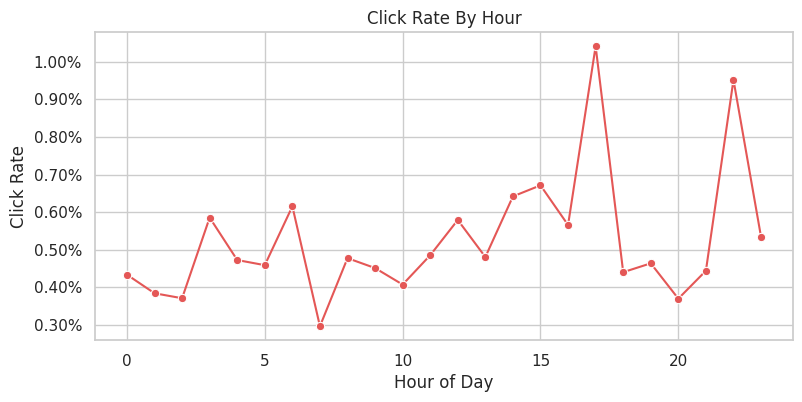

,hour,rows,click_rate
0,0,8070,0.004337
1,1,9888,0.003843
2,2,9163,0.003711
3,3,8882,0.005855
4,4,7405,0.004727
5,5,7190,0.004590
6,6,7800,0.006154
7,7,8429,0.002966
8,8,9212,0.004776
9,9,9971,0.004513


In [33]:
hourly_ctr = (
    df.groupby("hour")
    .agg(rows=("click", "size"), click_rate=("click", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=hourly_ctr, x="hour", y="click_rate", marker="o", ax=ax, color="#E45756")
ax.set_title("Click Rate By Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Click Rate")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
plt.show()

hourly_ctr


The hourly CTR table checks whether reward rates drift by time of day. If time patterns are visible, diagnostics or model features should account for them.


## OPE Readiness Checklist

This cell turns the main EDA findings into a checklist. A dataset is ready for introductory OPE if:

- every row has an action
- every row has a reward
- every row has a positive logged propensity
- the action space has repeated observations
- the logged policy explores the available actions

Passing these checks does not prove any evaluation policy will be easy to estimate. It only tells us the basic data ingredients are present.


In [34]:
# OPE readiness checklist.
ope_checks = pd.DataFrame(
    [
        {
            "check": "logged action is present",
            "value": df["item_id"].notna().all(),
            "detail": f"{df['item_id'].isna().sum()} missing item_id values",
        },
        {
            "check": "observed reward is present",
            "value": df["click"].notna().all(),
            "detail": f"{df['click'].isna().sum()} missing click values",
        },
        {
            "check": "propensity score is present",
            "value": df["propensity_score"].notna().all(),
            "detail": f"{df['propensity_score'].isna().sum()} missing propensity values",
        },
        {
            "check": "propensity score is positive",
            "value": bool((df["propensity_score"] > 0).all()),
            "detail": f"minimum propensity = {df['propensity_score'].min():.6f}",
        },
        {
            "check": "multiple actions observed",
            "value": df["item_id"].nunique() > 1,
            "detail": f"{df['item_id'].nunique()} unique items",
        },
        {
            "check": "each action has repeated support",
            "value": action_summary["rows"].min() > 1,
            "detail": f"minimum rows per item = {action_summary['rows'].min()}",
        },
        {
            "check": "item context covers logged actions",
            "value": df_with_items[item_feature_cols].isna().any(axis=1).sum() == 0,
            "detail": f"{df_with_items[item_feature_cols].isna().any(axis=1).sum()} rows missing item features",
        },
    ]
)

ope_checks


,check,value,detail
0,logged action is present,True,0 missing item_id values
1,observed reward is present,True,0 missing click values
2,propensity score is present,True,0 missing propensity values
3,propensity score is positive,True,minimum propensity = 0.029412
4,multiple actions observed,True,34 unique items
5,each action has repeated support,True,minimum rows per item = 5342
6,item context covers logged actions,True,0 rows missing item features


The readiness checklist summarizes whether the log has the essentials for OPE: rewards, actions, propensities, support, and enough sample size. Passing these checks justifies moving from EDA to estimator design.


### Baseline Behavior Policy Value

This cell estimates the observed value of the behavior policy in the sample. Because the logged data comes from the behavior policy itself, the average click rate is the direct sample estimate of behavior-policy value.

In later notebooks, off-policy evaluation will ask a harder question: what would the value have been under a different policy that selected different item probabilities for each context?


In [35]:
behavior_policy_value = pd.Series(
    {
        "behavior_policy": BEHAVIOR_POLICY,
        "campaign": CAMPAIGN,
        "sample_rows": len(df),
        "observed_policy_value_click_rate": df["click"].mean(),
        "standard_error": df["click"].std(ddof=1) / np.sqrt(len(df)),
    }
).to_frame("value")

behavior_policy_value


,value
behavior_policy,random
campaign,men
sample_rows,200000
observed_policy_value_click_rate,0.005190
standard_error,0.000161


The observed behavior-policy value is the logged baseline. It gives a reference point for whether evaluated policies appear better or worse offline.


#### Cache A Lightweight Analysis Sample

This final code cell writes the sampled and joined table to `data/processed/open_bandit_random_men_sample.parquet`. The next notebook can read this parquet file quickly and avoid repeated scans of the zip archive.

The cached file is a convenience artifact, not a new source of truth. The original downloaded zip remains the raw dataset.


In [36]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
processed_sample_path = PROCESSED_DIR / "open_bandit_random_men_sample.parquet"

df_with_items.to_parquet(processed_sample_path, index=False)

processed_sample_path


PosixPath('/home/apex/Documents/portfolio/data/processed/open_bandit_random_men_sample.parquet')

This cell saves reusable outputs for downstream notebooks or the final report. Persisting these artifacts makes the project modular and prevents later notebooks from repeating expensive or fragile setup work.


## Takeaways and Next Step

The `random/men` Open Bandit slice is suitable for off-policy evaluation because it has the core OPE ingredients: logged actions, binary rewards, positive behavior-policy propensities, and context features.

The most important practical finding is that the random policy gives broad action support. That makes it a strong starting point for IPS and SNIPS in Notebook 2. The reward is sparse, so later notebooks should pay close attention to estimator variance and compare direct IPS estimates against more stable doubly robust estimates.
